In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from diff_diff import CallawaySantAnna, plot_event_study
import numpy as np
from scipy import stats
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from run_event_study import run_event_study
from run_event_study_2 import (
    estimate_event_study,
    run_event_study_panels,
    csdid_like_cevent
)

from pathlib import Path
import importlib.util

utils_path = Path.cwd().resolve().parents[3] / "src/2_data_analysis/utils/plot_style.py"

spec = importlib.util.spec_from_file_location("plot_style", utils_path)
plot_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plot_style)

## **Estimation**

Using <code>diff-diff</code> python package that reproduces the results of using csdid2 in Stata.

### **Baseline event study**

In [2]:
# ── Load & prepare data ────────────────────────────────────────────────────────
df = pd.read_csv("../../../../data/output/conflict_level/windows/conflict_windows_random_matching_agreement_active_6_1.csv")

df['is_treated_window'] = df['is_treated_window'] * 18       # replace is_treated_window * 18
df['window_t']  = df['window_t'] + 18               # replace window_t + 18
df['window_id_num'] = df['window_id_num'].astype(int)
df['window_t'] = df['window_t'].astype(int)
df = df.sort_values(['window_id_num', 'window_t']).reset_index(drop=True)

/var/folders/fz/1mp_qssx1z546qc9z63nq3rm0000gn/T/ipykernel_60694/3150380787.py:2: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../../data/output/conflict_level/windows/conflict_windows_random_matching_agreement_active_6_1.csv")


In [5]:
df.groupby('window_id_num')['window_t'].count()

window_id_num
0       37
1       37
2       37
3       37
4       37
        ..
1219    37
1220    37
1221    37
1222    37
1223    37
Name: window_t, Length: 1224, dtype: int64

Average post-treatment effect (periods 1 to 18): 

 Treated W  Control W  Estimate  Std. Err.  p-value  CI Lower  CI Upper
       204       1020   -0.6323     0.1772   0.0004   -0.9797    -0.285


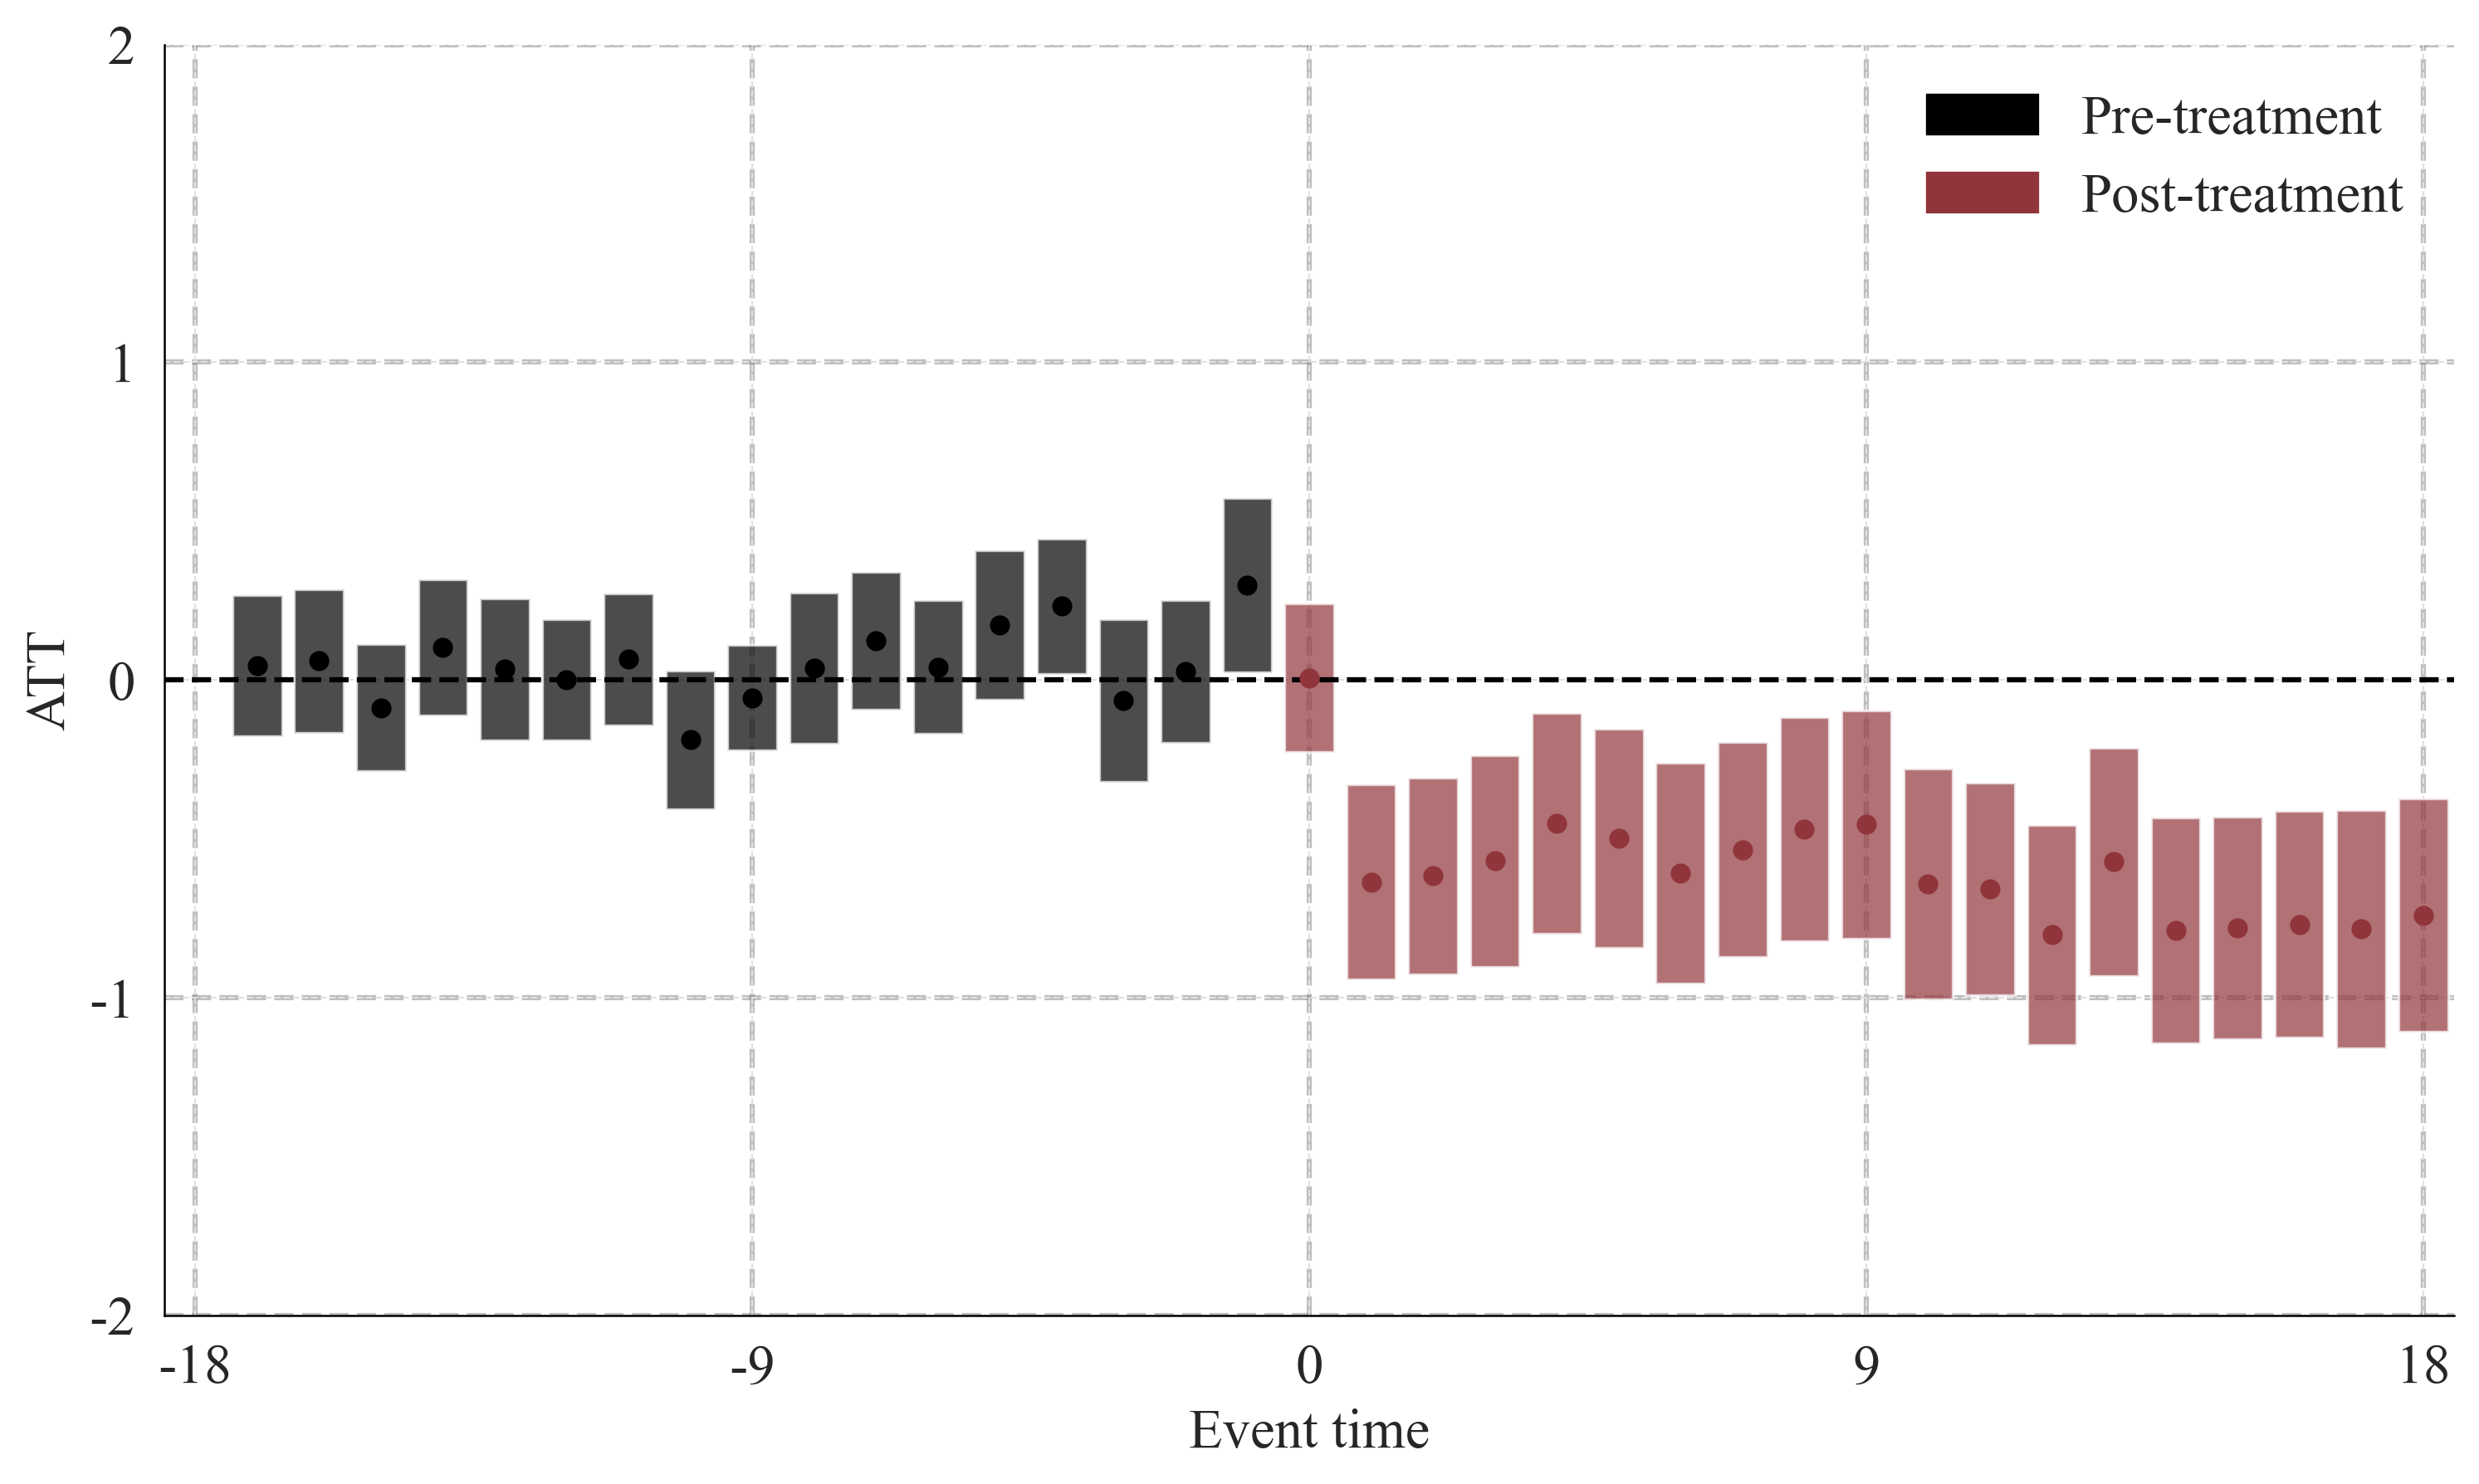

,period,effect,se,ci_lb,ci_ub
0,-17,0.044526,0.113791,-0.178504,0.267556
1,-16,0.059240,0.115247,-0.166645,0.285125
2,-15,-0.087413,0.101459,-0.286272,0.111447
3,-14,0.102793,0.109588,-0.111999,0.317585
4,-13,0.033019,0.114001,-0.190423,0.256460
5,-12,-0.000154,0.097232,-0.190730,0.190421
6,-11,0.064340,0.106041,-0.143502,0.272181
7,-10,-0.188917,0.111519,-0.407495,0.029660
8,-9,-0.056134,0.084839,-0.222418,0.110151
9,-8,0.036996,0.121349,-0.200848,0.274840


In [3]:
run_event_study(
    df=df,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num",
)

In [5]:
#for each window comput the mean of log_best between t = -6 and t=-1
# 1. Compute group mean only for t in [12,17]
pre6_mean = (
    df[df["window_t"].between(12, 17)]
    .groupby("window_id_num")["log_best"]
    .mean()
)

# 2. Map back to all rows in the group
df["y_pre6"] = df["window_id_num"].map(pre6_mean)
df[['window_id_num', 'window_t', 'log_best', 'y_pre6']].head(20)


,window_id_num,window_t,log_best,y_pre6
0,0,0,0.0,0.0
1,0,1,0.0,0.0
2,0,2,0.0,0.0
3,0,3,0.0,0.0
4,0,4,0.0,0.0
5,0,5,0.0,0.0
6,0,6,0.0,0.0
7,0,7,0.0,0.0
8,0,8,0.0,0.0
9,0,9,0.0,0.0


Average post-treatment effect (periods 1 to 18): 

 Treated W  Control W  Estimate  Std. Err.  p-value  CI Lower  CI Upper
       204       1020    1.5199     2.9573   0.6073   -4.2764    7.3162


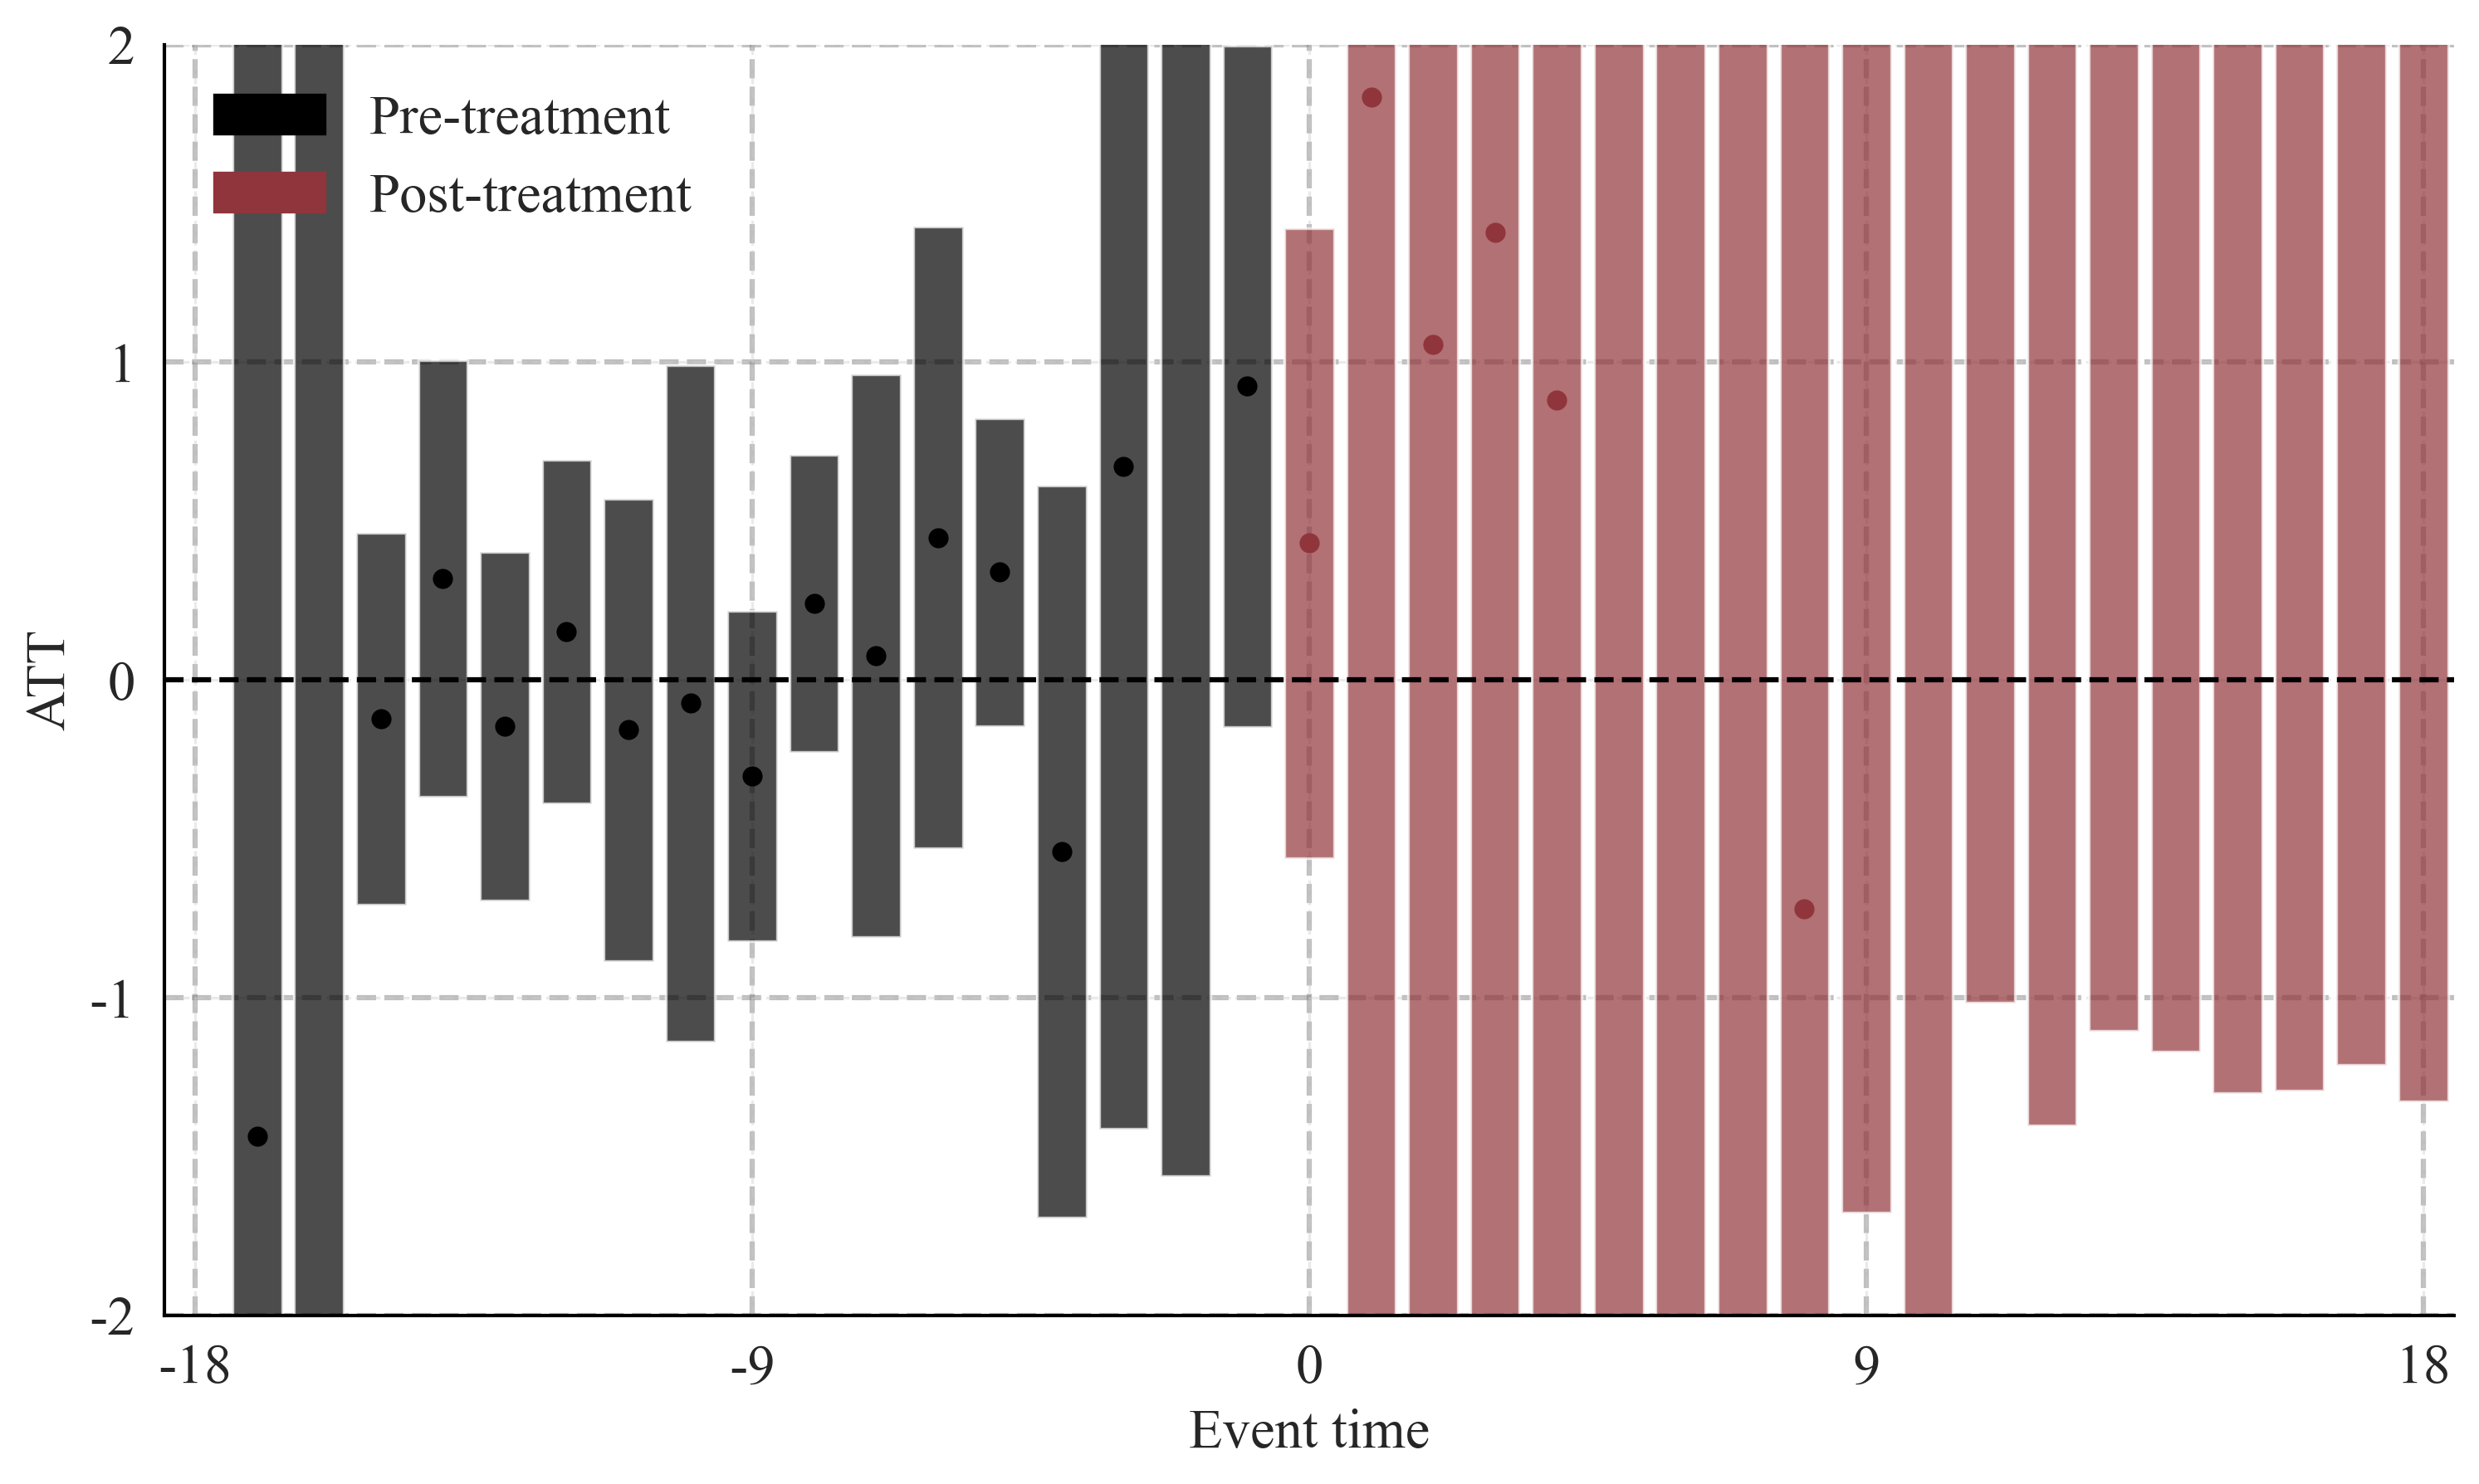

,period,effect,se,ci_lb,ci_ub
0,-17,-1.436283,2.033818,-5.422567,2.550001
1,-16,-3.928561,4.272238,-12.302149,4.445026
2,-15,-0.122917,0.298694,-0.708358,0.462524
3,-14,0.319084,0.350009,-0.366933,1.005101
4,-13,-0.145750,0.280273,-0.695085,0.403584
5,-12,0.151961,0.276041,-0.389080,0.693001
6,-11,-0.157242,0.371528,-0.885438,0.570953
7,-10,-0.073733,0.542799,-1.137619,0.990154
8,-9,-0.303403,0.265209,-0.823212,0.216407
9,-8,0.239930,0.238830,-0.228176,0.708036


In [6]:
run_event_study(
    df=df,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num",
    controls = ["y_pre6"]
)

In [7]:
def make_quarter_panel(
    df,
    unit="window_id_num",
    month_t="window_t",
    cluster="isocode_num",
    gvar_month="is_treated_window",   # en tu caso: 18 treated, 0 never
    best_col="best",
):
    dfq = df.copy()

    # q_t = ceil(window_t/3)
    # (si window_t es 1..36, esto da 1..12 como en Stata)
    dfq["q_t"] = np.ceil(dfq[month_t] / 3).astype(int)

    # gvar en escala trimestral: si tratado en mes 18 -> tratado en quarter ceil(18/3)=6
    treated_month = 18
    dfq["is_treated_window_q"] = np.where(
        dfq[gvar_month] == treated_month,
        int(np.ceil(treated_month / 3)),
        0
    )

    # total(best) por unit x quarter
    q_agg = (
        dfq.groupby([unit, "q_t"], as_index=False)
           .agg(
               fatal_q=(best_col, "sum"),
               # preservar cluster y gvar (son constantes dentro de unit)
               **{
                   cluster: (cluster, "first"),
                   "is_treated_window_q": ("is_treated_window_q", "first"),
               }
           )
    )

    # log(fatal_q + 1)
    q_agg["log_best_q"] = np.log(q_agg["fatal_q"] + 1)

    # panel final: 1 fila por unit-quarter
    q_panel = q_agg[[unit, cluster, "q_t", "is_treated_window_q", "log_best_q"]].copy()
    return q_panel

df_q = make_quarter_panel(
    df,
    unit="window_id_num",
    month_t="window_t",
    cluster="isocode_num",
    gvar_month="is_treated_window",
    best_col="best"
)

Average post-treatment effect (periods 1 to 6): 

 Treated W  Control W  Estimate  Std. Err.  p-value  CI Lower  CI Upper
       204       1020   -0.4917      0.178   0.0057   -0.8405   -0.1428


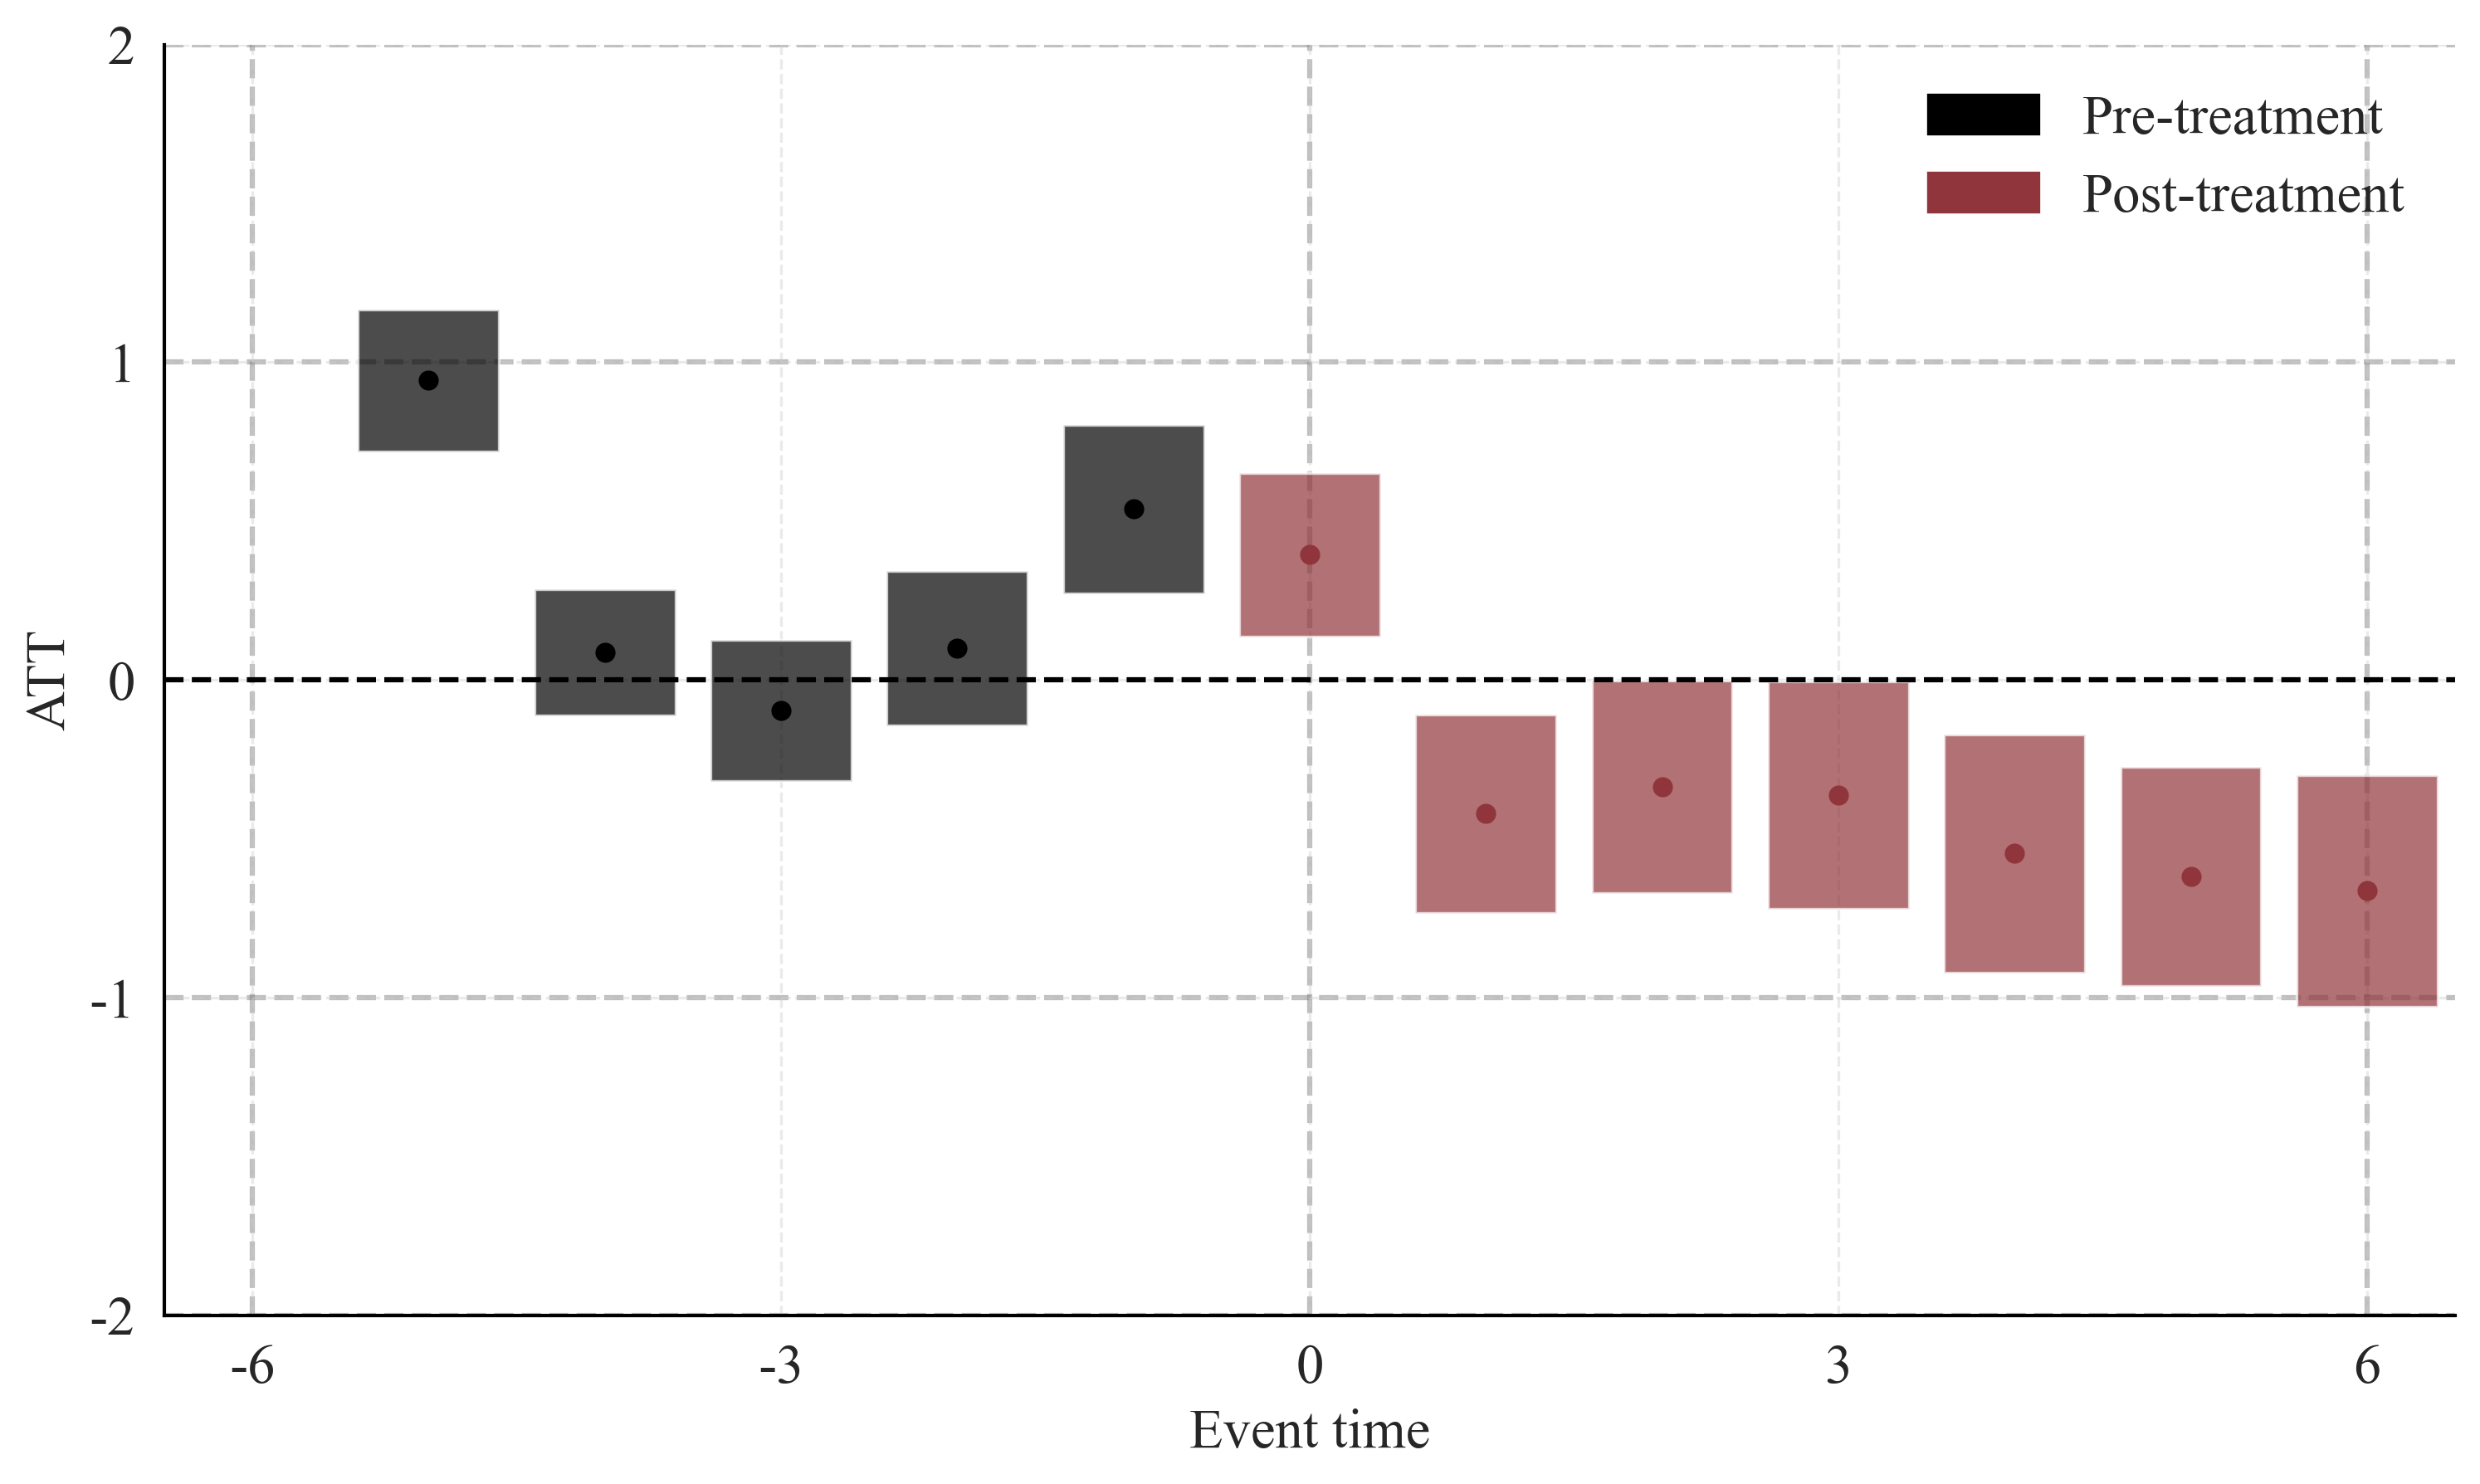

,period,effect,se,ci_lb,ci_ub
0,-5,0.942750,0.113732,0.719836,1.165664
1,-4,0.086545,0.101935,-0.113248,0.286338
2,-3,-0.096620,0.113725,-0.319520,0.126281
3,-2,0.099717,0.123488,-0.142320,0.341754
4,-1,0.537536,0.134887,0.273156,0.801915
5,0,0.393879,0.131357,0.136418,0.651339
6,1,-0.421311,0.159387,-0.733710,-0.108912
7,2,-0.336329,0.170502,-0.670513,-0.002145
8,3,-0.363308,0.182550,-0.721105,-0.005511
9,4,-0.546583,0.191445,-0.921815,-0.171351


In [8]:
run_event_study(
    df=df_q,
    outcome="log_best_q",
    unit="window_id_num",
    time="q_t",
    first_treat="is_treated_window_q",
    cluster="isocode_num",
    dyn=6,
    quarterly=True
)

## **Country Panel**

In [6]:
df = pd.read_csv("../../../../data/output/country_level/windows/country_windows_random_matching_ceasfire_agreements_mentions_18_1.csv")

df['is_treated_window'] = df['is_treated_window'] * 18       # replace is_treated_window * 18
df['window_t']  = df['window_t'] + 18               # replace window_t + 18
df['window_id_num'] = df['window_id_num'].astype(int)
df['window_t'] = df['window_t'].astype(int)
df = df.sort_values(['window_id_num', 'window_t']).reset_index(drop=True)

/var/folders/fz/1mp_qssx1z546qc9z63nq3rm0000gn/T/ipykernel_60694/1945934236.py:1: DtypeWarning: Columns (127) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../../data/output/country_level/windows/country_windows_random_matching_ceasfire_agreements_mentions_18_1.csv")


In [7]:
df[(df['matched_treated_window_id']=='MOZ_23') & (df['window_t']==18)][['isocode', 'year_mo']]

,isocode,year_mo
2904,BTN,2005-04-01
7825,GIN,2020-02-01
12635,LSO,2011-07-01
13079,MDA,2015-04-01
20368,SLV,2022-12-01


[('CMR', '2017-06-01'), ('GBR', '2022-02-01'), ('MEX', '2015-06-01'), ('MMR', '1991-05-01'), ('SLE', '1992-05-01')]


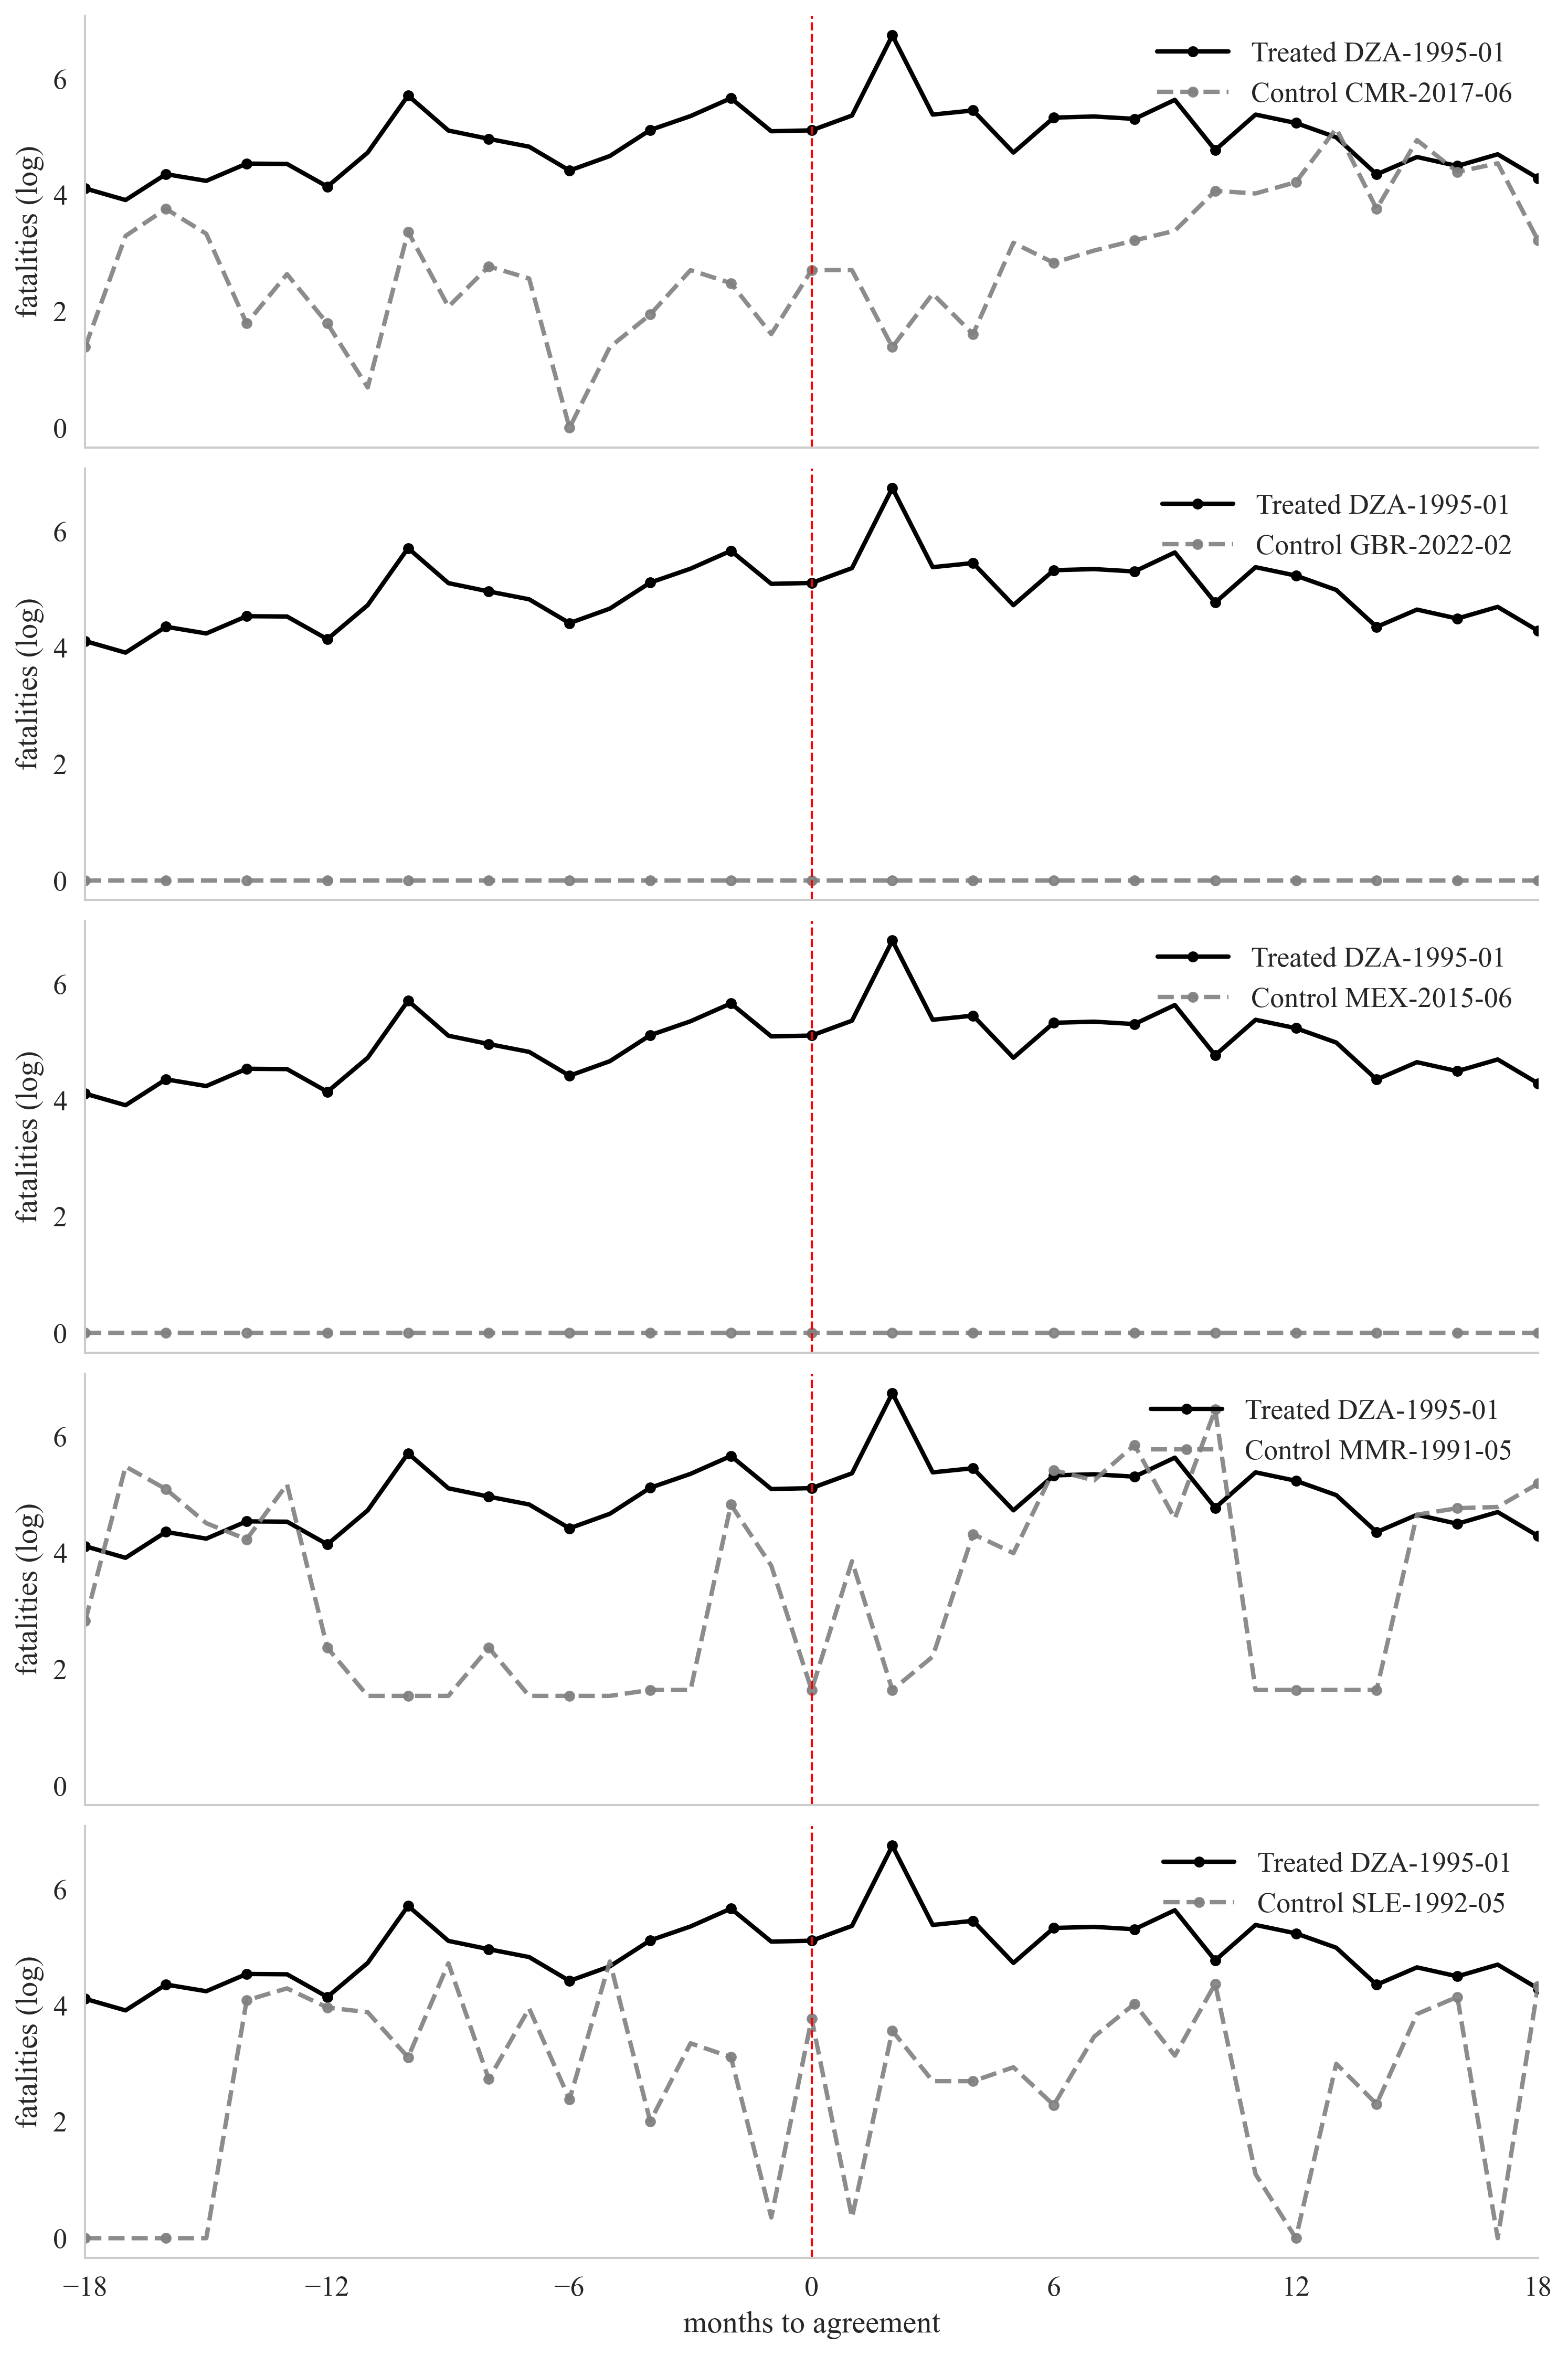

In [10]:
from plot_control_treated_windows import plot_event_study_subplots_matched
treated_window_id = df[df['is_treated_window']==18]['window_id'].unique().tolist()[25]
df_controls = df.loc[
    (df['matched_treated_window_id'] == treated_window_id) & (df['window_t']==18)]

controls = list(zip(df_controls['isocode'], df_controls['year_mo']))
print(controls)
 #11 or #18
plot_event_study_subplots_matched(
    df=df.sort_values(["window_id", "window_t"]),
    treated_window_id=treated_window_id,
    outcome_col="log_best",
    max_controls=6,   # pon 6 si quieres ver varios
    window=18
)

Average post-treatment effect (periods 1 to 18): 

 Treated W  Control W  Estimate  Std. Err.  p-value  CI Lower  CI Upper
       112        560   -0.4709     0.2348   0.0449    -0.931   -0.0107


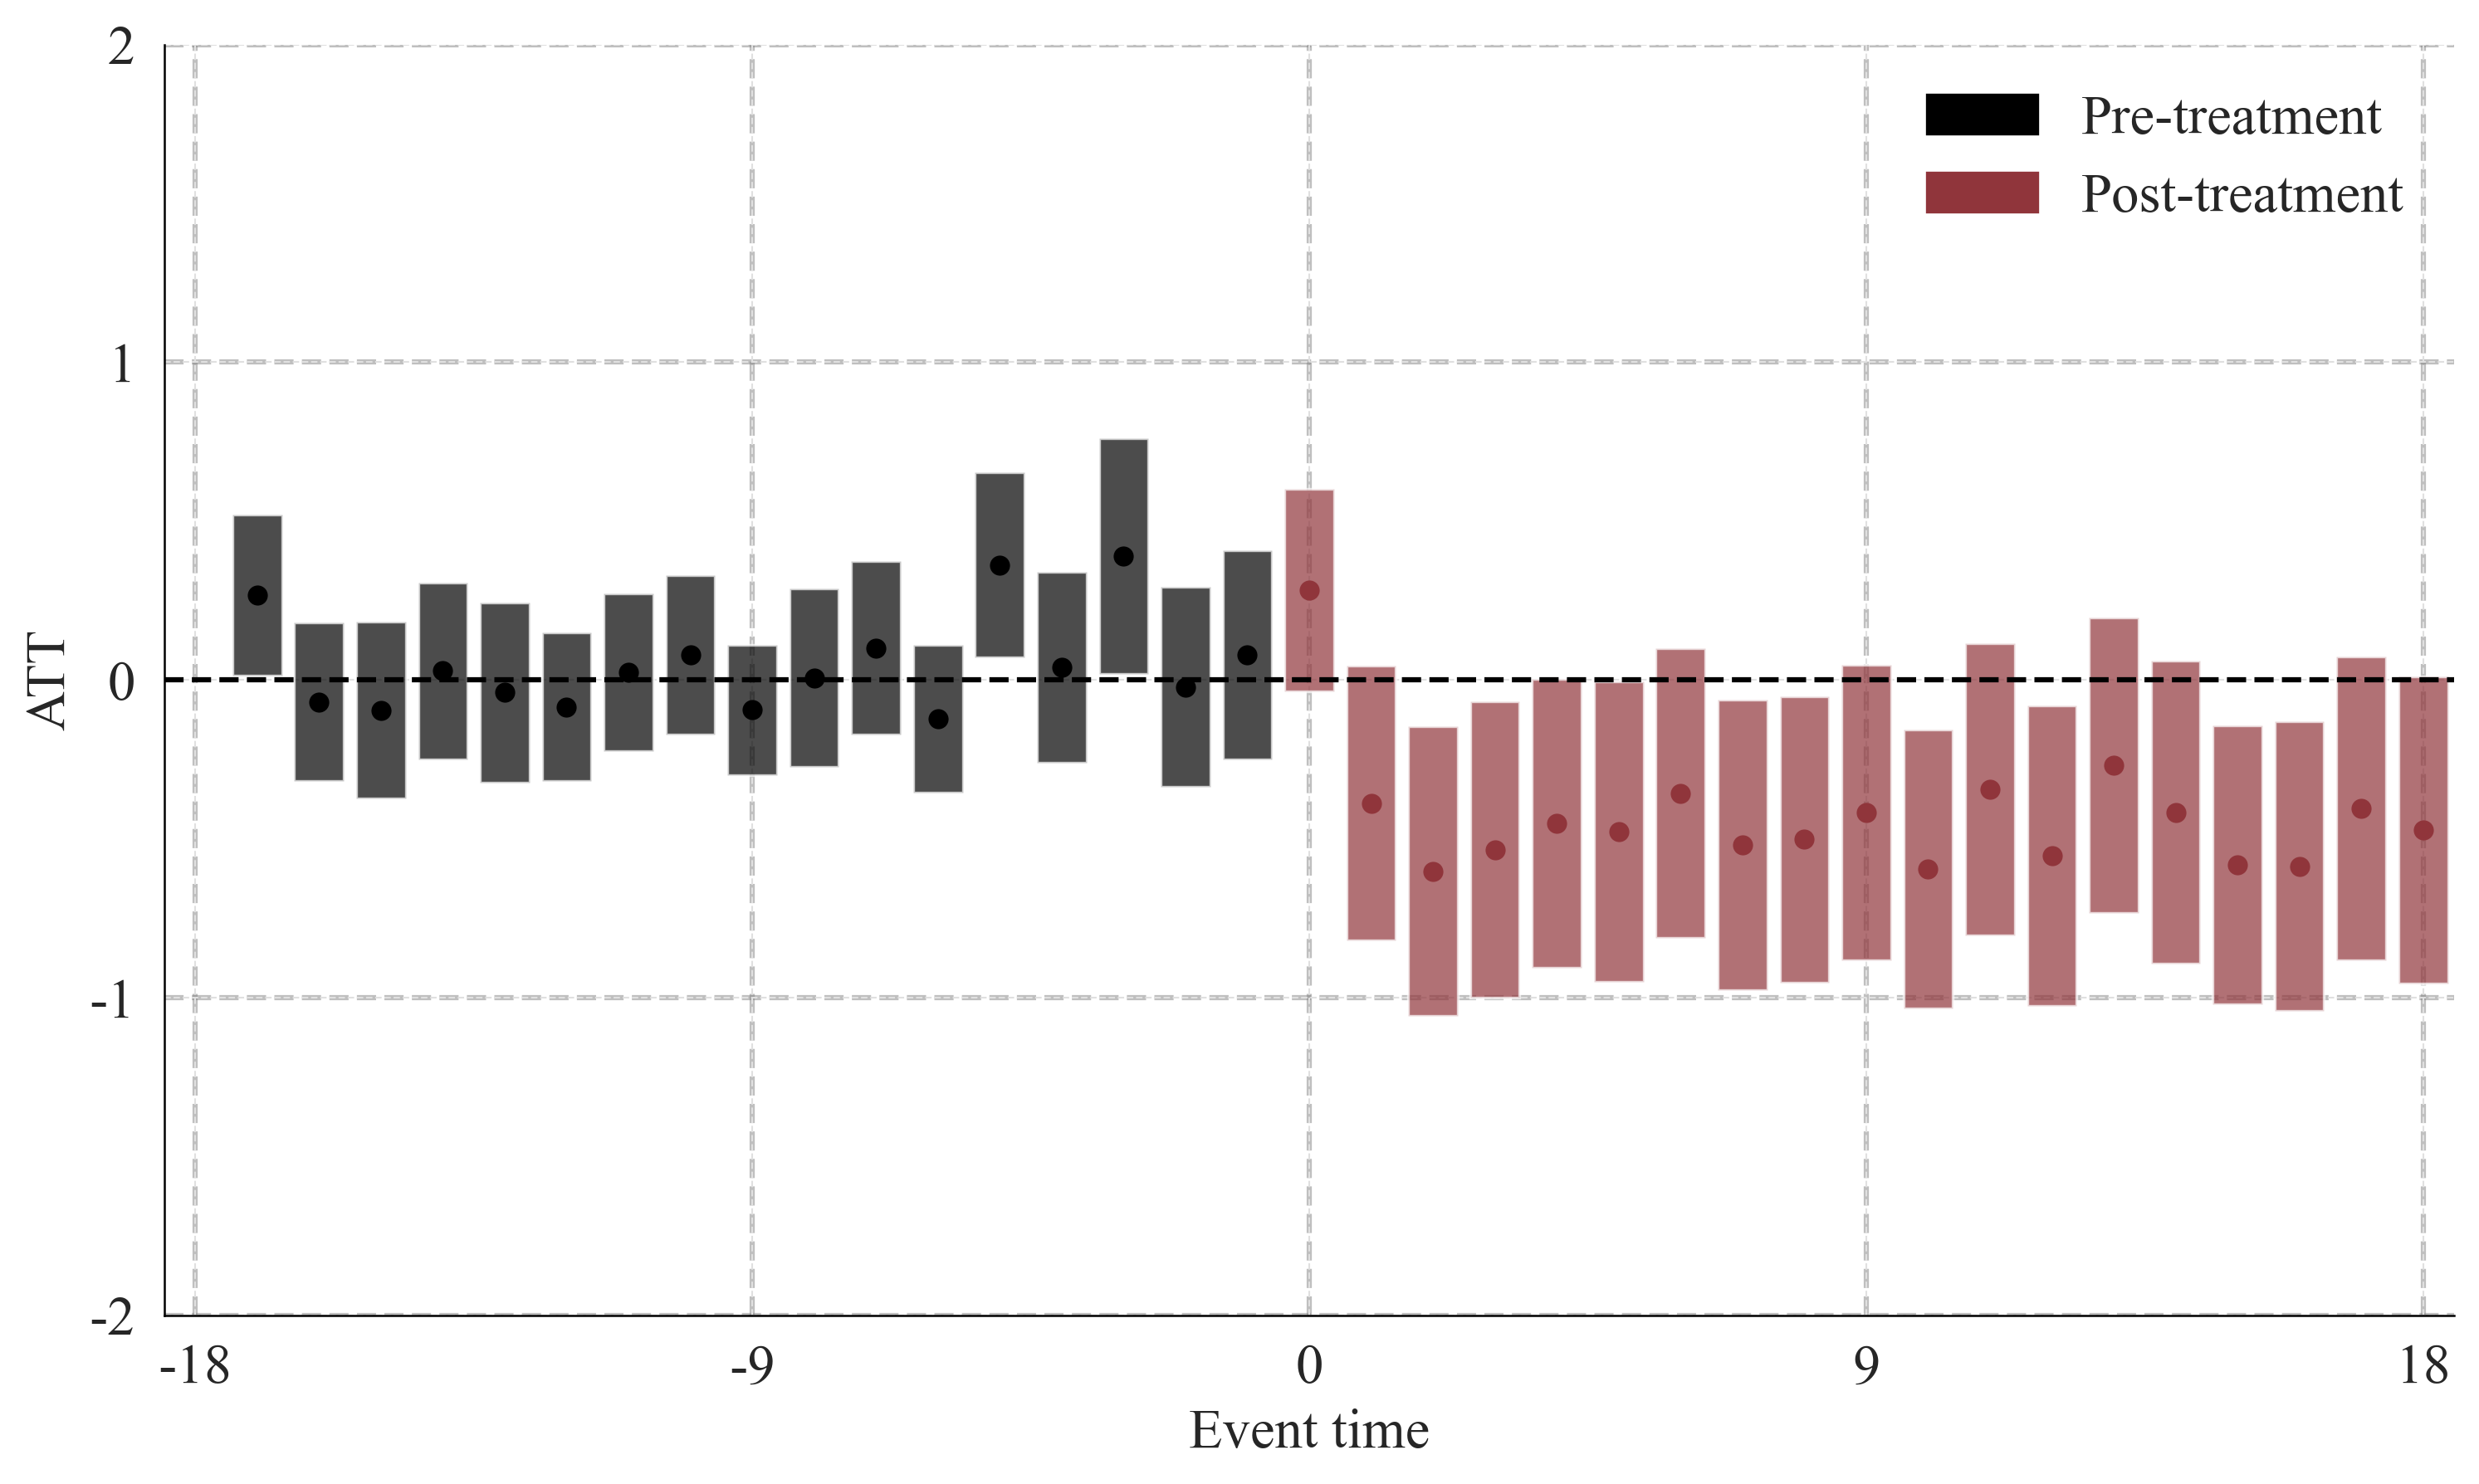

,period,effect,se,ci_lb,ci_ub
0,-17,0.266733,0.129217,0.013468,0.519998
1,-16,-0.068982,0.127355,-0.318598,0.180633
2,-15,-0.095738,0.142189,-0.374429,0.182952
3,-14,0.028316,0.142048,-0.250097,0.306729
4,-13,-0.039772,0.144923,-0.323821,0.244277
5,-12,-0.084699,0.119563,-0.319042,0.149645
6,-11,0.024846,0.126597,-0.223284,0.272976
7,-10,0.078841,0.127399,-0.170861,0.328543
8,-9,-0.094308,0.104713,-0.299545,0.110929
9,-8,0.006634,0.143171,-0.273981,0.287250


In [8]:
run_event_study(
    df=df,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num",
)

Average post-treatment effect (periods 1 to 18): 

 Treated W  Control W  Estimate  Std. Err.  p-value  CI Lower  CI Upper
       112        560   -0.3083     0.3003   0.3046    -0.897    0.2804


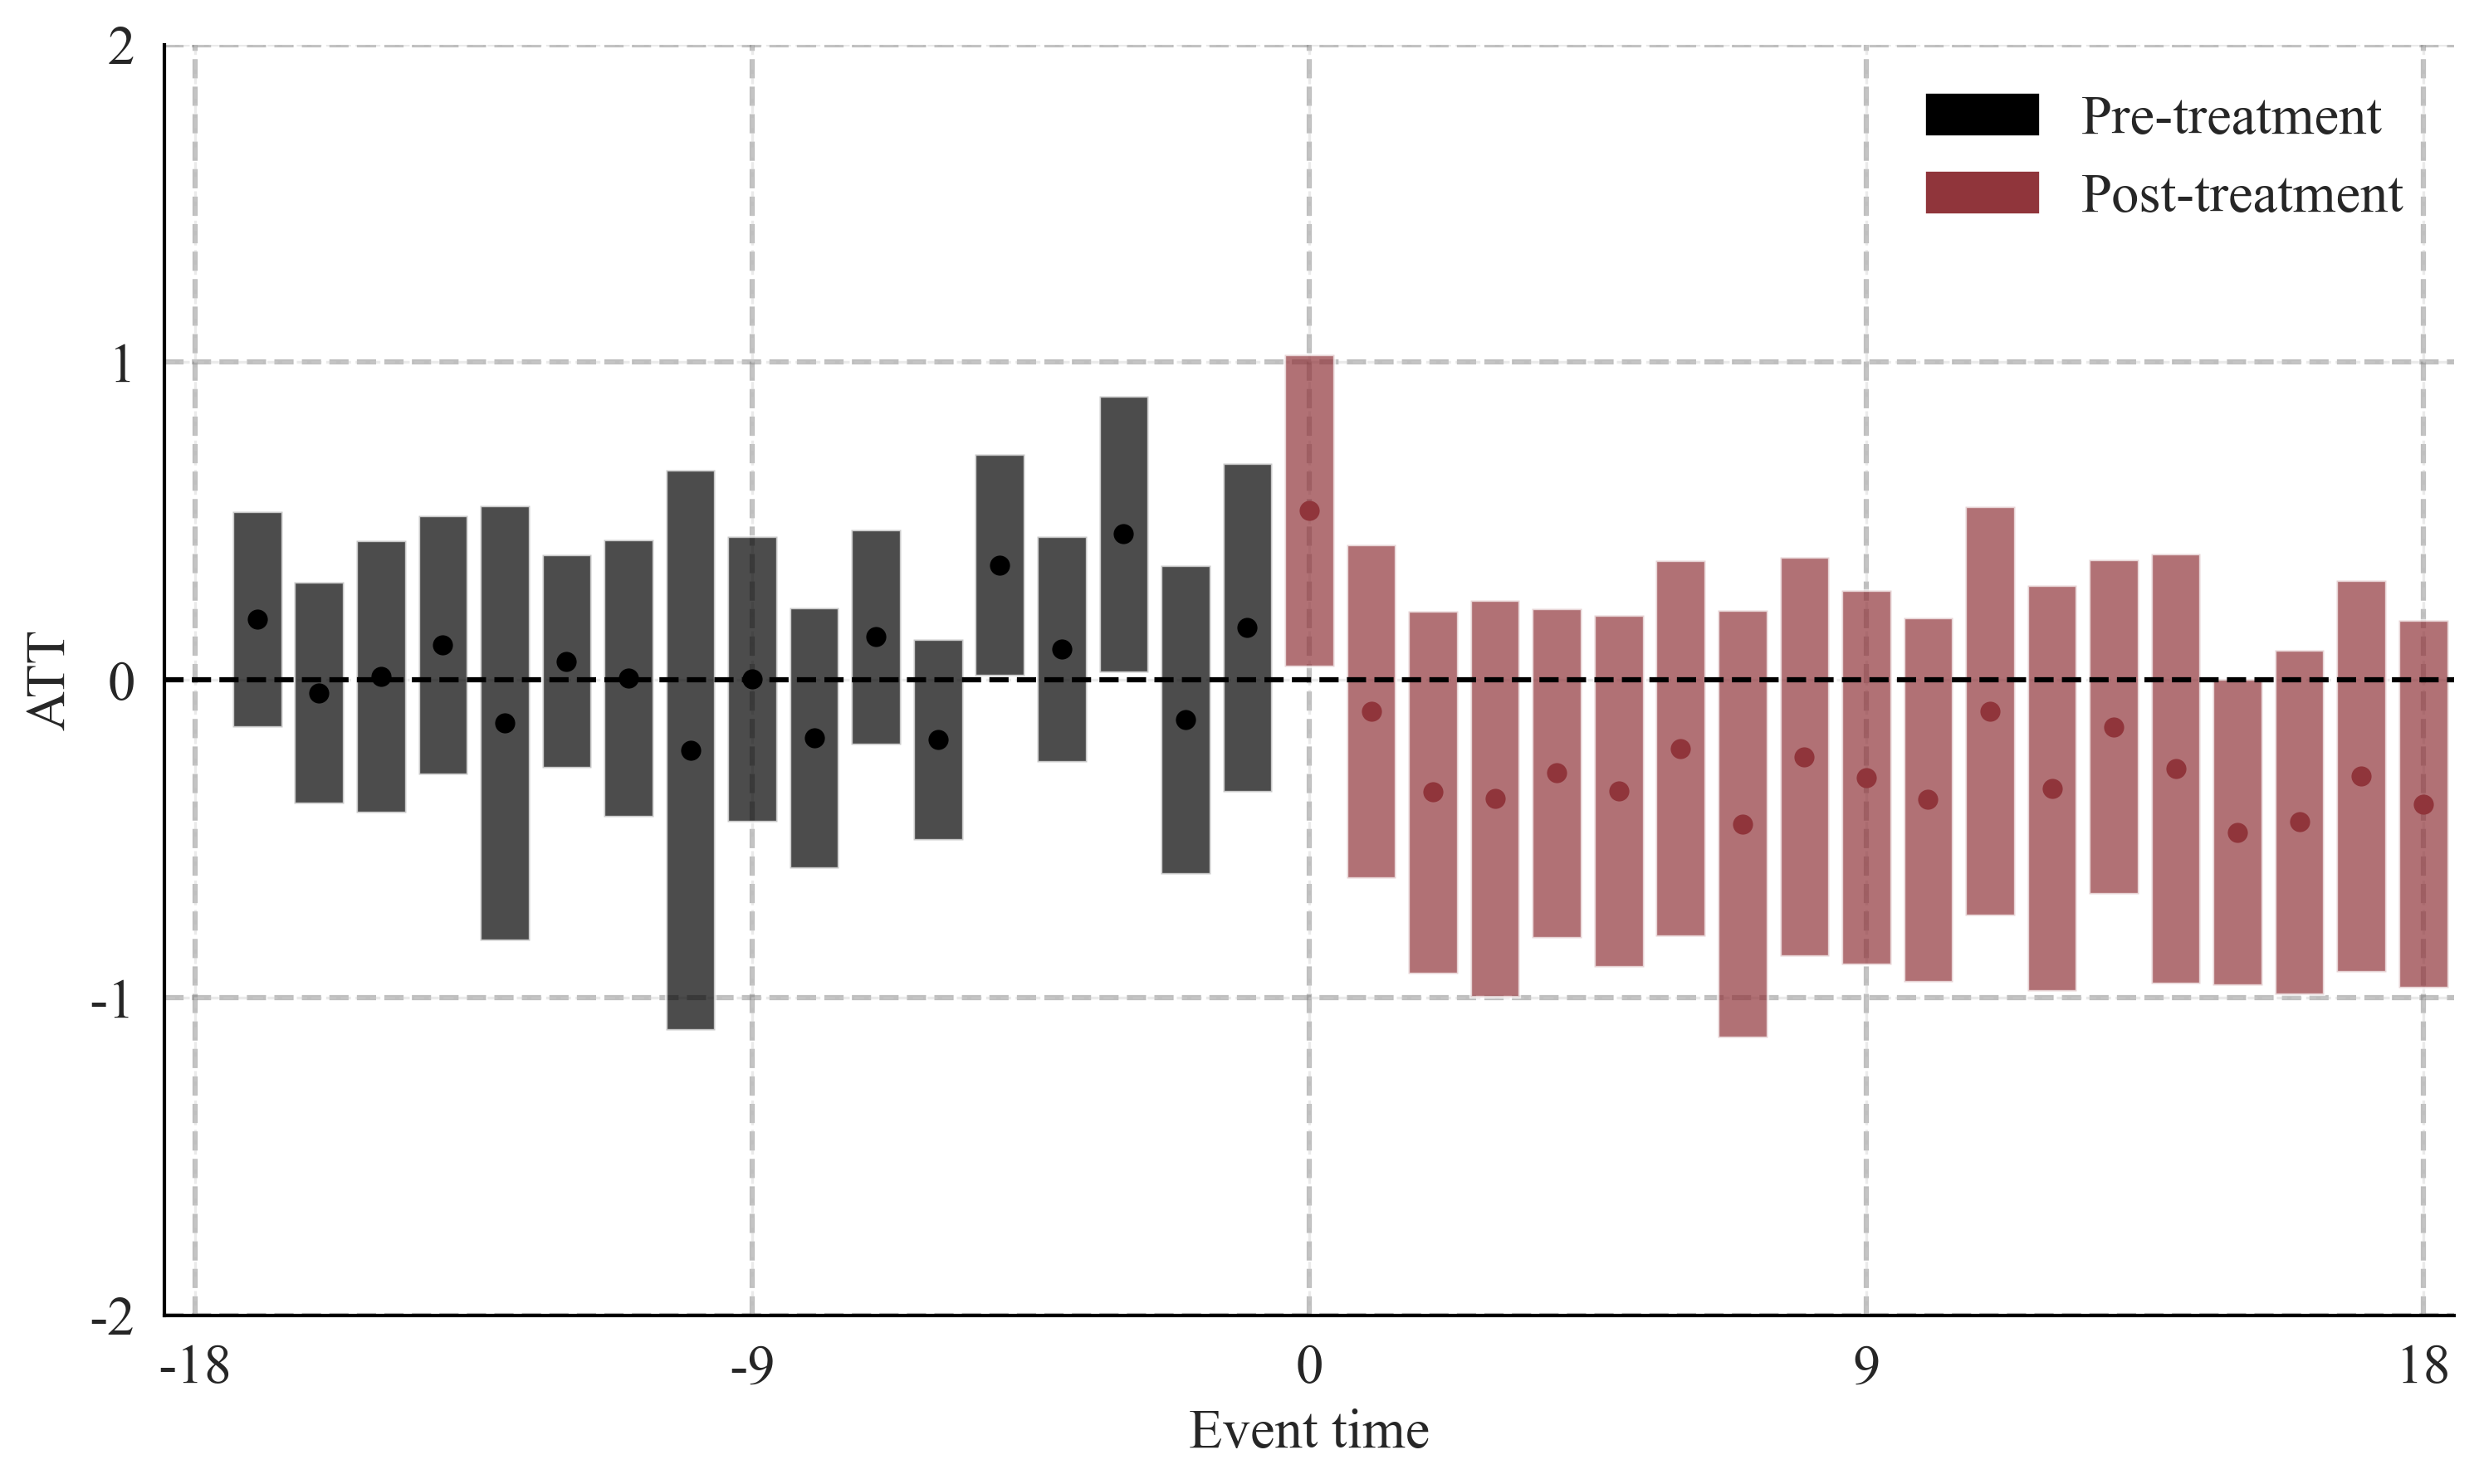

,period,effect,se,ci_lb,ci_ub
0,-17,0.190314,0.173496,-0.149739,0.530367
1,-16,-0.040623,0.177860,-0.389228,0.307982
2,-15,0.010830,0.218649,-0.417722,0.439383
3,-14,0.109723,0.207621,-0.297215,0.516660
4,-13,-0.135320,0.348974,-0.819309,0.548670
5,-12,0.058913,0.171664,-0.277549,0.395375
6,-11,0.006012,0.222237,-0.429572,0.441595
7,-10,-0.221321,0.449780,-1.102889,0.660247
8,-9,0.001922,0.229216,-0.447341,0.451184
9,-8,-0.183218,0.209472,-0.593783,0.227346


In [12]:
#for each window comput the mean of log_best between t = -6 and t=-1
# 1. Compute group mean only for t in [12,17]
pre6_mean = (
    df[df["window_t"].between(12, 17)]
    .groupby("window_id_num")["log_best"]
    .mean()
)

# 2. Map back to all rows in the group
df["y_pre6"] = df["window_id_num"].map(pre6_mean)
run_event_study(
    df=df,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num",
    controls = ["y_pre6"]
)


In [13]:
df_q = make_quarter_panel(
    df,
    unit="window_id_num",
    month_t="window_t",
    cluster="isocode_num",
    gvar_month="is_treated_window",
    best_col="best"
)

Average post-treatment effect (periods 1 to 6): 

 Treated W  Control W  Estimate  Std. Err.  p-value  CI Lower  CI Upper
       112        560    -0.402     0.2353   0.0876   -0.8632    0.0592


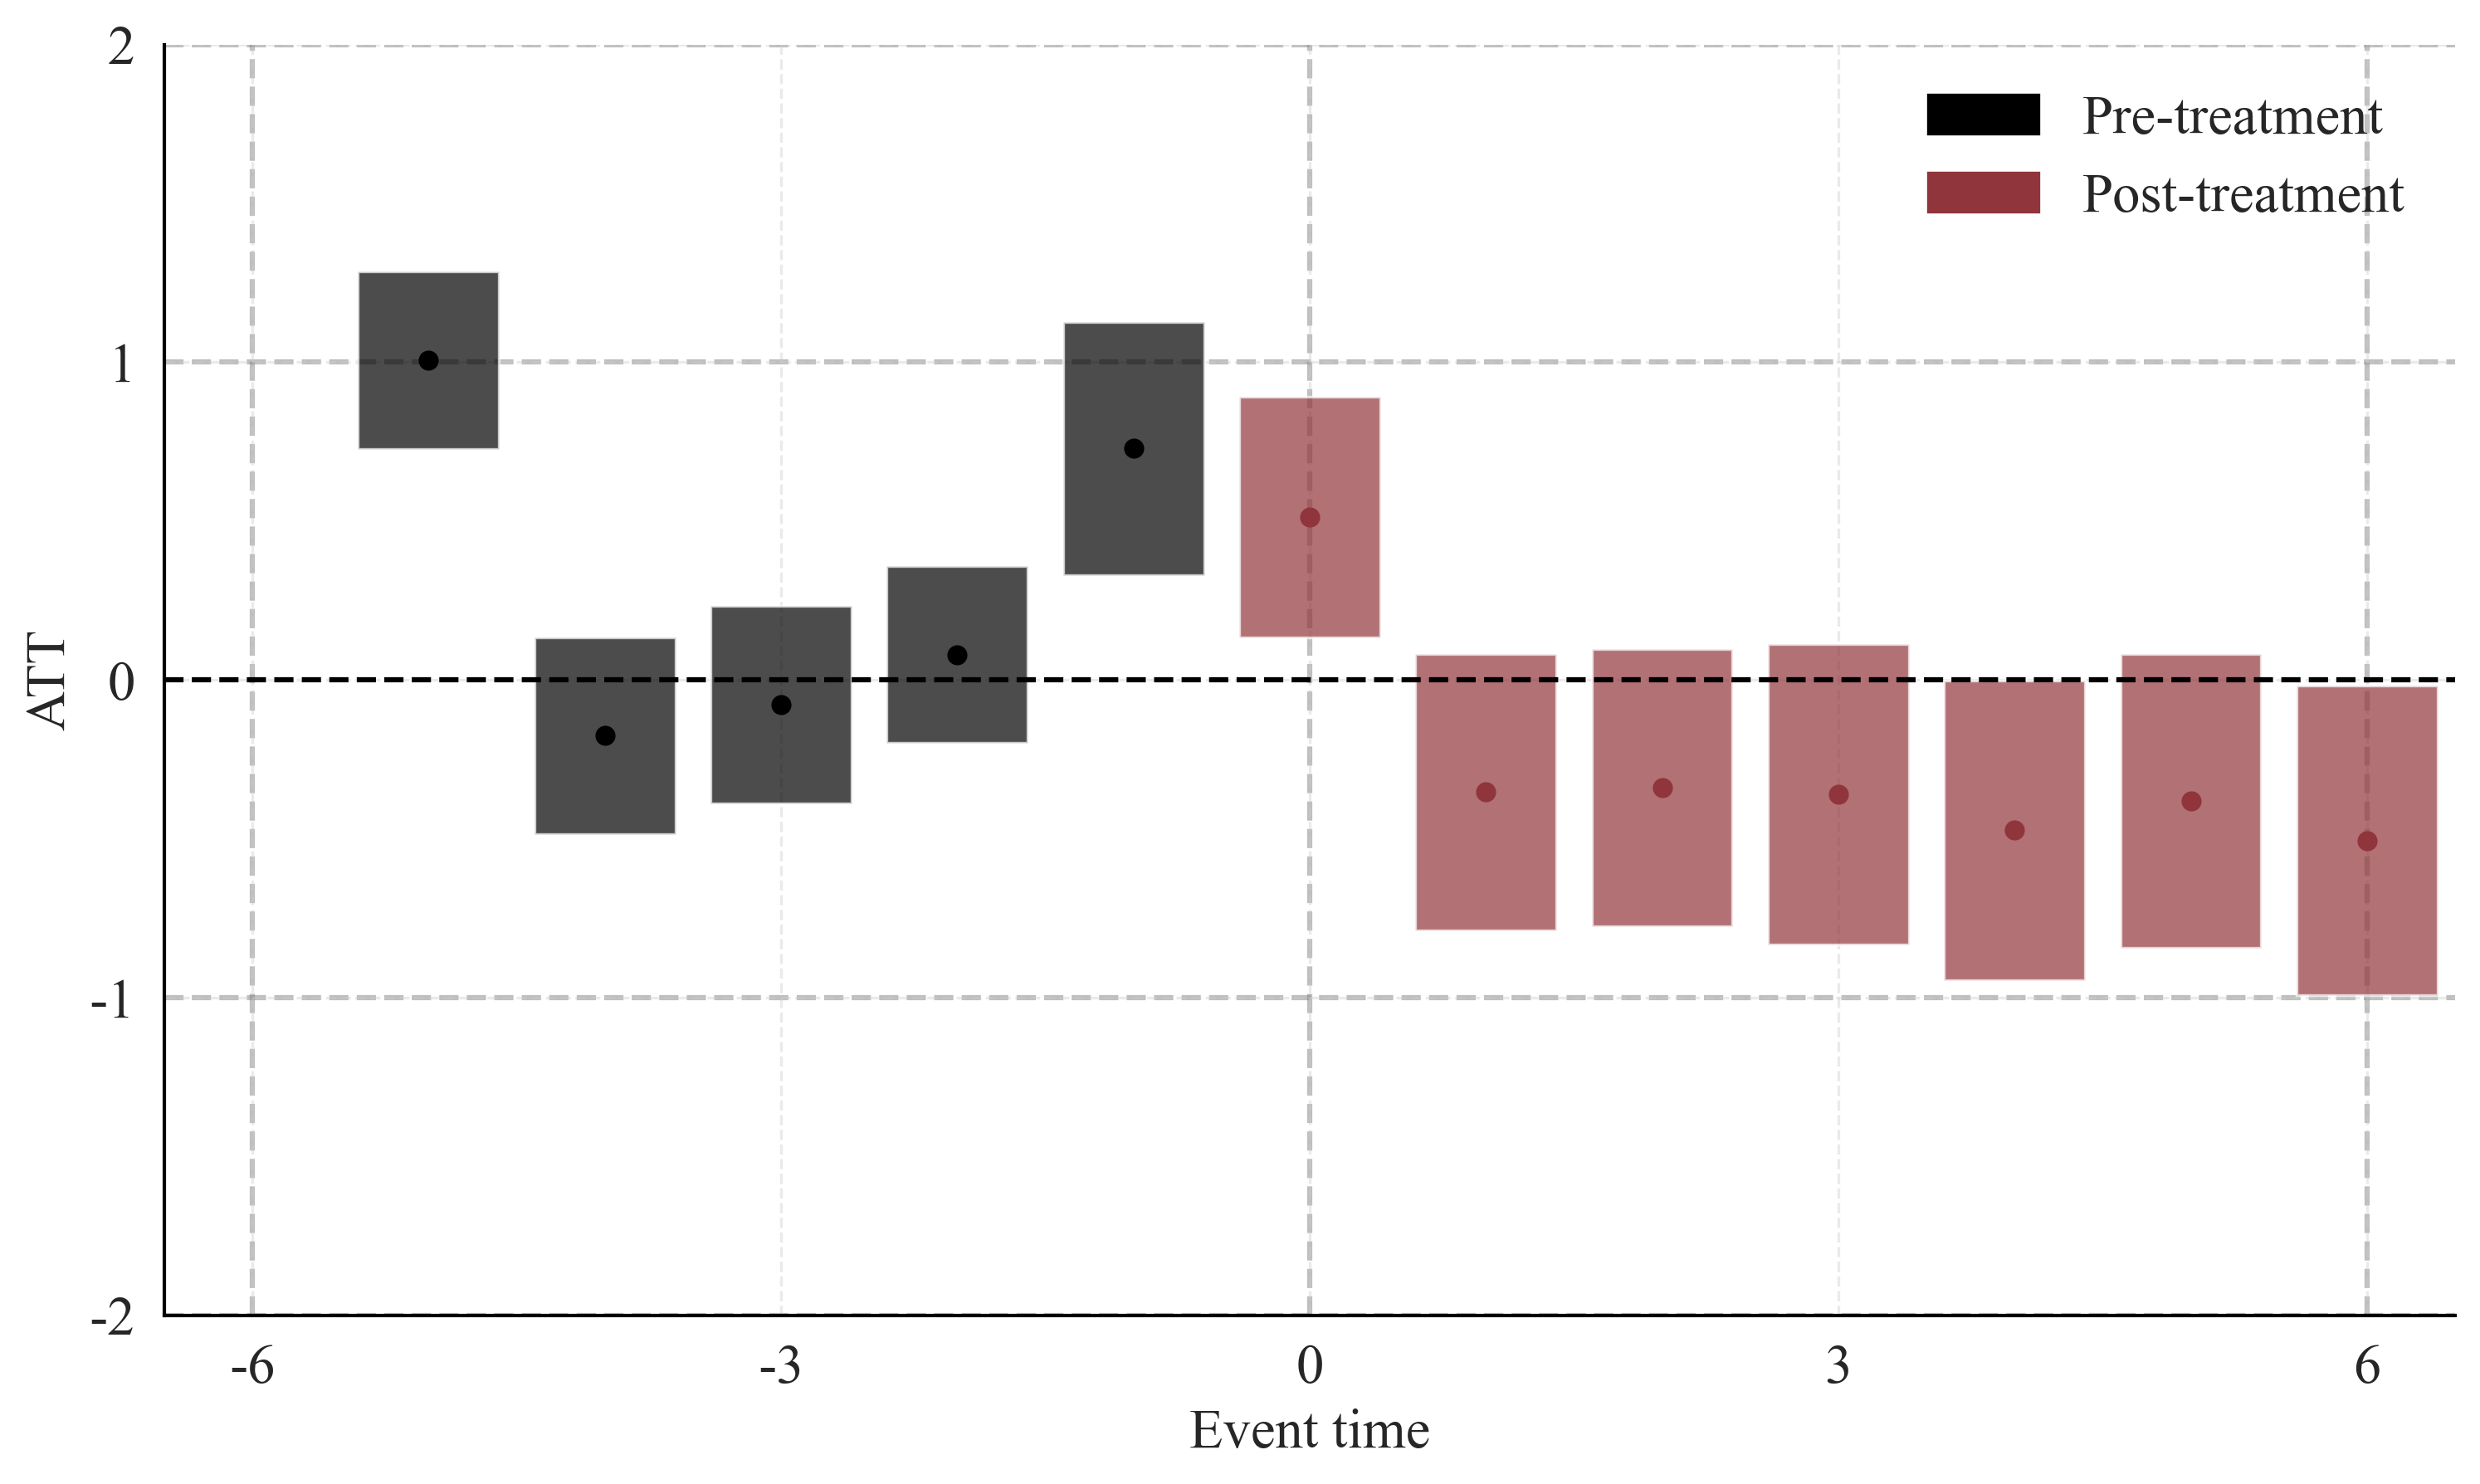

,period,effect,se,ci_lb,ci_ub
0,-5,1.006063,0.142396,0.726966,1.285160
1,-4,-0.175692,0.157797,-0.484974,0.133591
2,-3,-0.078565,0.158650,-0.389518,0.232389
3,-2,0.079804,0.142317,-0.199137,0.358745
4,-1,0.728110,0.203646,0.328964,1.127255
5,0,0.512227,0.193245,0.133467,0.890986
6,1,-0.352671,0.221935,-0.787665,0.082322
7,2,-0.338462,0.222754,-0.775059,0.098135
8,3,-0.360389,0.241170,-0.833083,0.112305
9,4,-0.473622,0.240503,-0.945007,-0.002237


In [14]:
run_event_study(
    df=df_q,
    outcome="log_best_q",
    unit="window_id_num",
    time="q_t",
    first_treat="is_treated_window_q",
    cluster="isocode_num",
    dyn=6,
    quarterly=True
)

## **TODO**

- Check the way I'm aggregatin the post estimation results so when computing the SE and CI I'm using the covariance matrix of the estimates and not just the SE of each estimate. This is important because the estimates are correlated across time periods. I think this is what csdid2 does but I need to check it.

ValueError: results.influence_functions is None. Check your diff-diff version / estimation settings.

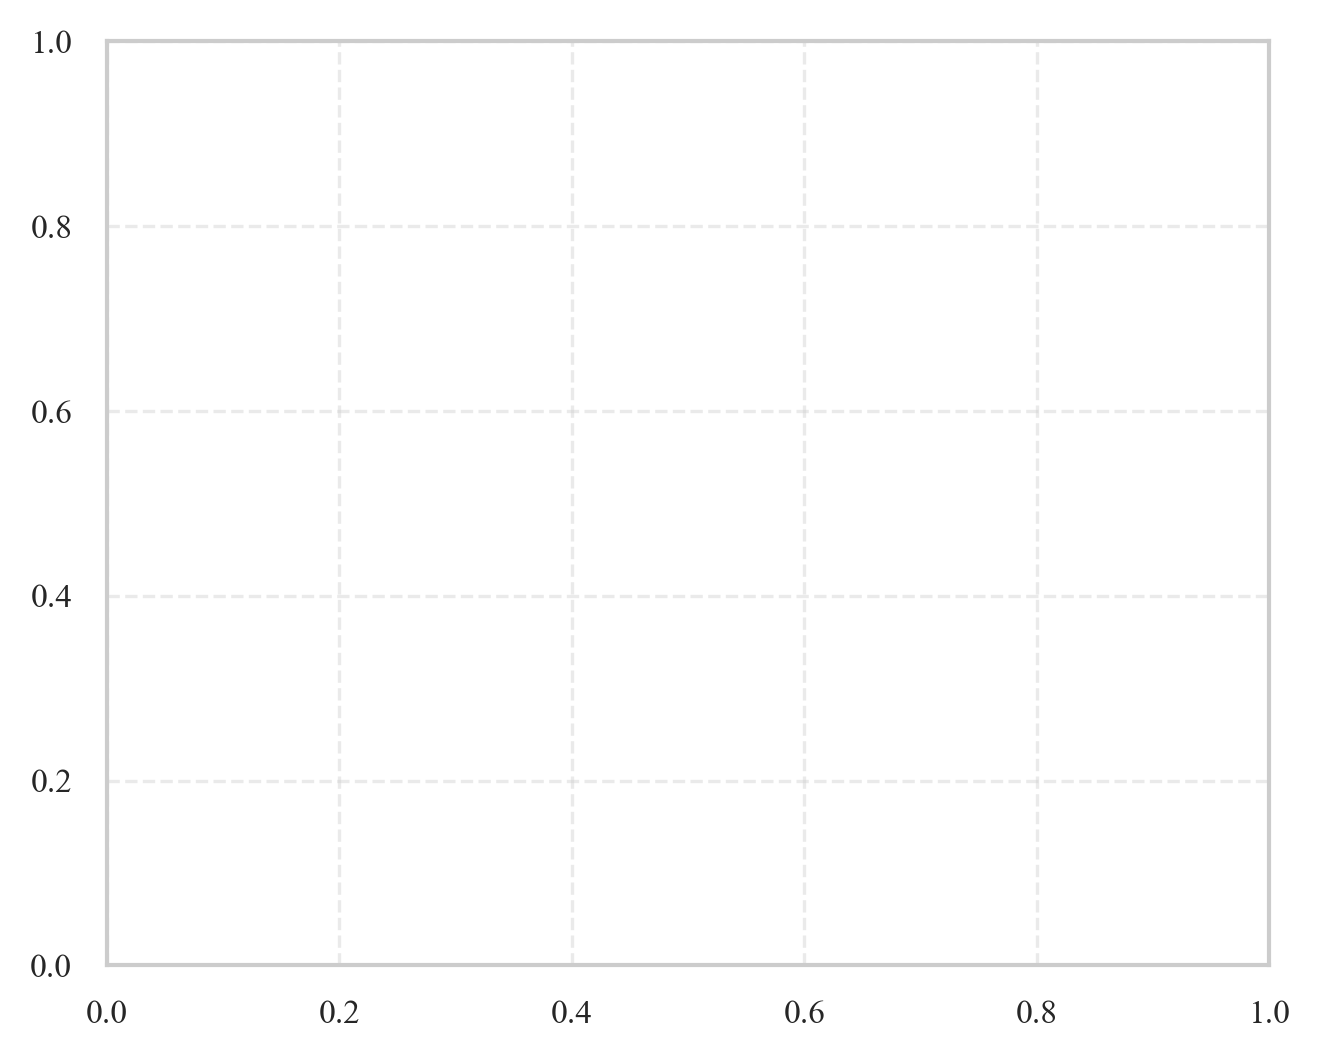

In [15]:
run_event_study_panels(
    df=df,
    subsets=[None],
    titles=[""],
    nrows=1,
    ncols=1,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num"
    
)

### **Baseline event study by low vs high pre-treatment violence**

In [ ]:
run_event_study_panels(
    df=df,
    subsets=[
        'intensity_level in ["high_intensity", "control"]',
        'intensity_level in ["low_intensity", "control"]'
    ],
    titles=["High intensity", "Low intensity"],
    nrows=1,
    ncols=2,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num"
)

In [ ]:
mechs = [
    "is_has_info_mecha_window",
    "is_has_commit_pol_mecha_window",
    "is_has_commit_econ_mecha_window",
    "is_has_commit_mil_mecha_window",
    "is_has_cost_mecha_window",
    "is_has_balancing_mecha_window"
]

subsets = [
    f"({m} == 1) | (is_treated_window == 0)"
    for m in mechs
]

titles = [
    "Info mechanism",
    "Political commitment",
    "Economic commitment",
    "Military commitment",
    "Cost mechanism",
    "Balancing mechanism"
]

run_event_study_panels(
    df=df,
    subsets=subsets,
    titles=titles,
    nrows=2,
    ncols=3,
    outcome="log_best",
    unit="window_id_num",
    time="window_t",
    first_treat="is_treated_window",
    cluster="isocode_num"
)